In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [109]:
file_path = 'diamonds.csv'

In [110]:
try:
    df = pd.read_csv(file_path)
    print("Dataset load successfully.")
except:
    raise FileNotFoundError(
        f"Dataset not found at: (file_path)\n"
        "Upload the CSV file and update the file_path variable"
    )


Dataset load successfully.


In [111]:
print("\nFIRST FIVE RECORDS")
df.head()


FIRST FIVE RECORDS


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [112]:
print("\nDATASET DIMENSIONS")
print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])


DATASET DIMENSIONS
Rows:  53940
Columns:  11


In [113]:
df.shape

(53940, 11)

In [114]:
print("\nCOLUMN NAMES")
print(df.columns.tolist())


COLUMN NAMES
['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


In [115]:
print("\nDATA TYPES AND MISSING VALUES")
df.info()


DATA TYPES AND MISSING VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [116]:
print("\nDESCRIPTIVE STATISTICS")
df.describe()


DESCRIPTIVE STATISTICS


,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [117]:
print("\nMISSING VALUES PER COLUMN")
df.isnull().sum()


MISSING VALUES PER COLUMN


Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [118]:
print("\nDUPLICATED SUM")
df.duplicated().sum()


DUPLICATED SUM


np.int64(0)


CORRELATION MATRIX


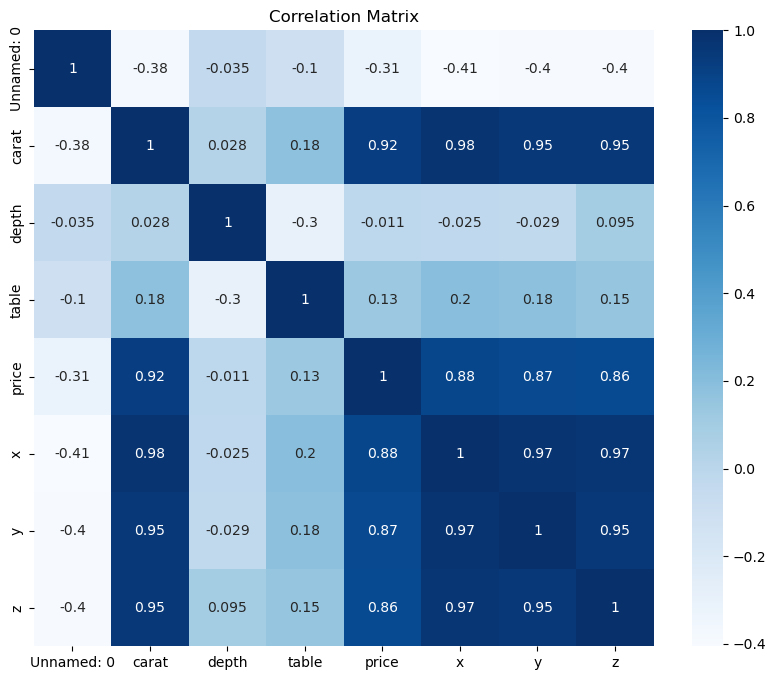

In [119]:
print("\nCORRELATION MATRIX")
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Blues")

plt.title("Correlation Matrix")
plt.show()

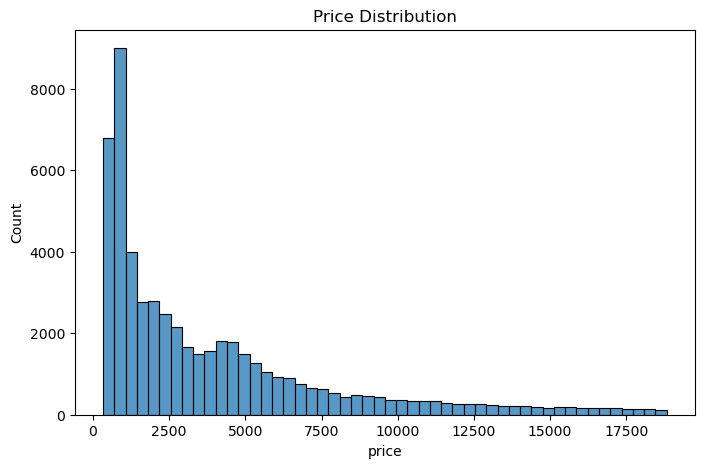

In [120]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution")
plt.show()

In [121]:
for col in ["x", "y", "z"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

df.reset_index(drop=True, inplace=True)

In [122]:
# Reset index
df.reset_index(drop=True, inplace=True)

In [123]:
# We drop Unnamed column (irrelevant)
df.drop(columns=["Unnamed: 0"], inplace=True)

In [124]:
#Input and Output
X = df.drop('price', axis=1)
y = np.log1p(df['price'])

In [125]:
print("\nFEATURES")
print(X.head())


FEATURES
   carat      cut color clarity  depth  table     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0  4.34  4.35  2.75


In [126]:
print(X.columns.tolist())
print(X.head())

['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
   carat      cut color clarity  depth  table     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0  4.34  4.35  2.75


In [127]:
print("\nTARGET")
print(y.head())


TARGET
0    5.789960
1    5.789960
2    5.793014
3    5.814131
4    5.817111
Name: price, dtype: float64


In [128]:
# We will use this in transformer
categorical_features = ["cut", "color", "clarity"]

numerical_features = [
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z"
]

In [129]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_features
        )
    ]
)

In [130]:
#We split the data into testing and training
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    random_state=42)

In [131]:
# We create a pipeline of the model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [132]:
# We train the model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carat','cut','color',...,'x','y','z']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the outpu

In [133]:
log_predictions = model.predict(X_test)
predictions = np.expm1(log_predictions)
actual = np.expm1(y_test)

In [134]:
regressor = model.named_steps["regressor"]

print("\nMODEL INTERCEPT")
print(f"{regressor.intercept_:.4f}")

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": regressor.coef_
})

print("\nMODEL COEFFICIENTS")
print(coefficient_table.round(4))

print("\nINTERPRETATION OF COEFFICIENTS")

for feature, coefficient in zip(feature_names, regressor.coef_):

    direction = "increase" if coefficient >= 0 else "decrease"

    print(
        f"A one-unit increase in {feature}, while holding the other "
        f"features constant, is associated with a {direction} of "
        f"{abs(coefficient):.4f} in the predicted log diamond price."
    )


MODEL INTERCEPT
7.1576

MODEL COEFFICIENTS
               Feature  Coefficient
0           num__carat      -0.4795
1           num__depth       0.0390
2           num__table       0.0208
3               num__x       0.7629
4               num__y       0.3817
5               num__z       0.4205
6        cat__cut_Good       0.0718
7       cat__cut_Ideal       0.1407
8     cat__cut_Premium       0.1149
9   cat__cut_Very Good       0.1019
10        cat__color_E      -0.0581
11        cat__color_F      -0.0970
12        cat__color_G      -0.1630
13        cat__color_H      -0.2563
14        cat__color_I      -0.3776
15        cat__color_J      -0.5155
16     cat__clarity_IF       1.0790
17    cat__clarity_SI1       0.5718
18    cat__clarity_SI2       0.4071
19    cat__clarity_VS1       0.7863
20    cat__clarity_VS2       0.7185
21   cat__clarity_VVS1       0.9864
22   cat__clarity_VVS2       0.9173

INTERPRETATION OF COEFFICIENTS
A one-unit increase in num__carat, while holding the other f

In [135]:
log_predictions = model.predict(X_test)

actual = np.expm1(y_test)
predictions = np.expm1(log_predictions)

results = X_test.copy()

results["Actual Price ($)"] = actual.values
results["Predicted Price ($)"] = predictions

results["Residual ($)"] = (
    results["Actual Price ($)"] -
    results["Predicted Price ($)"]
)

results["Absolute Error ($)"] = (
    results["Residual ($)"].abs()
)

print("\nACTUAL AND PREDICTED DIAMOND PRICES")
print(results.round(2))


ACTUAL AND PREDICTED DIAMOND PRICES
       carat        cut color clarity  depth  table     x     y     z  \
1812    0.78  Very Good     E     SI1   60.9   57.0  5.93  5.97  3.62   
28698   0.31  Very Good     E     VS2   61.0   59.0  4.33  4.39  2.66   
21610   1.76      Ideal     I     SI2   61.2   55.0  7.79  7.76  4.76   
14128   0.91  Very Good     F    VVS2   62.6   59.0  6.10  6.16  3.84   
15507   1.48    Premium     H     SI2   59.7   59.0  7.46  7.42  4.44   
...      ...        ...   ...     ...    ...    ...   ...   ...   ...   
2012    0.78    Premium     D     SI1   61.8   59.0  5.93  5.88  3.65   
51495   0.70       Good     D     SI2   63.7   58.0  5.64  5.60  3.58   
7225    0.90      Ideal     H     VS1   61.8   56.0  6.18  6.24  3.84   
16828   1.50       Fair     I     SI2   64.8   58.0  7.05  7.15  4.60   
31955   0.30      Ideal     D     VS2   59.5   56.0  4.41  4.37  2.61   

       Actual Price ($)  Predicted Price ($)  Residual ($)  Absolute Error ($)  
1812 

In [136]:
mae = mean_absolute_error(actual, predictions)
mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(actual, predictions)

print("\nMODEL EVALUATION")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

print("\nEVALUATION INTERPRETATION")
print(
    f"On average, the model's predictions differ from the actual"
    f"diamond prices by approximately {mae:.2f}, based on MAE."
)

if r2 >= 0.90:
    print("The model explains the variation in the data very well")
elif r2 >= 0.70:
    print("The model demonstrates reasonably good predictive performance")
elif r2 >= 0.50:
    print("The model demonstrates moderate predictive performance.")
else:
    print("The model has limited predictive performance and may require "
    "more data or additional relevant features.")


MODEL EVALUATION
MAE : 400.09
MSE : 583676.32
RMSE: 763.99
R²  : 0.9617

EVALUATION INTERPRETATION
On average, the model's predictions differ from the actualdiamond prices by approximately 400.09, based on MAE.
The model explains the variation in the data very well


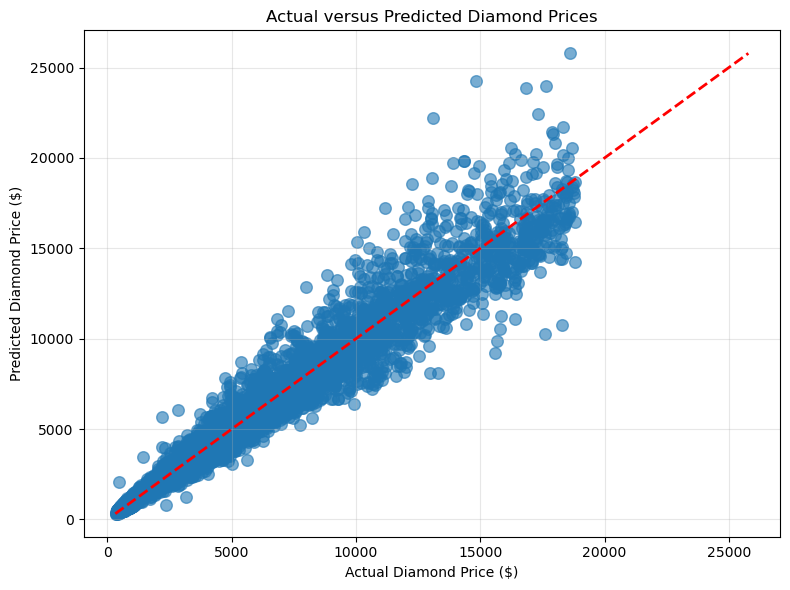

In [137]:
predictions = np.expm1(model.predict(X_test))

actual = np.expm1(y_test)

plt.figure(figsize=(8,6))

plt.scatter(
    actual,
    predictions,
    s=70,
    alpha=0.6
)

minimum_price = min(actual.min(), predictions.min())
maximum_price = max(actual.max(), predictions.max())

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--",
    color="red",
    linewidth=2
)

plt.xlabel("Actual Diamond Price ($)")
plt.ylabel("Predicted Diamond Price ($)")
plt.title("Actual versus Predicted Diamond Prices")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

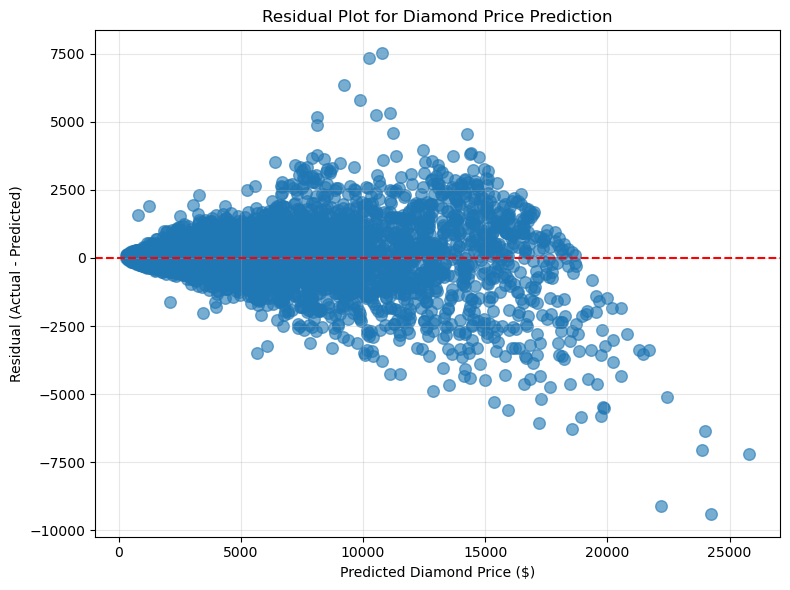

In [138]:
residuals = actual - predictions

plt.figure(figsize=(8,6))

plt.scatter(
    predictions,
    residuals,
    s=70,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Diamond Price ($)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot for Diamond Price Prediction")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [140]:
print("\nCUSTOM DIAMOND PRICE PREDICTION")

try:

    carat = float(input("Enter carat weight: "))
    cut = input("Enter cut (Fair, Good, Very Good, Premium, Ideal): ")
    color = input("Enter color (D, E, F, G, H, I, J): ").upper()
    clarity = input("Enter clarity (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF): ").upper()

    depth = float(input("Enter depth percentage: "))
    table = float(input("Enter table percentage: "))
    x = float(input("Enter length (x): "))
    y = float(input("Enter width (y): "))
    z = float(input("Enter depth (z): "))

    if carat <= 0:
        raise ValueError("Carat must be greater than zero.")

    if depth <= 0:
        raise ValueError("Depth must be greater than zero.")

    if table <= 0:
        raise ValueError("Table must be greater than zero.")

    if x <= 0 or y <= 0 or z <= 0:
        raise ValueError("Diamond dimensions must be greater than zero.")

    valid_cut = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
    valid_color = ["D", "E", "F", "G", "H", "I", "J"]
    valid_clarity = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

    if cut not in valid_cut:
        raise ValueError("Invalid cut.")

    if color not in valid_color:
        raise ValueError("Invalid color.")

    if clarity not in valid_clarity:
        raise ValueError("Invalid clarity.")

    user_diamond = pd.DataFrame({

        "carat": [carat],
        "cut": [cut],
        "color": [color],
        "clarity": [clarity],
        "depth": [depth],
        "table": [table],
        "x": [x],
        "y": [y],
        "z": [z]

    })

    print("\nDIAMOND INFORMATION")

    diamond_summary = pd.DataFrame({
        "Value": [
            carat,
            cut,
            color,
            clarity,
            depth,
            table,
            x,
            y,
            z
        ]
    },
    index=[
        "carat",
        "cut",
        "color",
        "clarity",
        "depth",
        "table",
        "length (x)",
        "width (y)",
        "depth (z)"
    ])

    print(diamond_summary)

    log_prediction = model.predict(user_diamond)[0]
    prediction = np.expm1(log_prediction)

    print("\nDIAMOND INFORMATION")
    print(f"Carat   : {carat}")
    print(f"Cut     : {cut}")
    print(f"Color   : {color}")
    print(f"Clarity : {clarity}")
    print(f"Depth   : {depth}")
    print(f"Table   : {table}")
    print(f"x        : {x}")
    print(f"y        : {y}")
    print(f"z        : {z}")

    print(f"\nEstimated Diamond Price: ${prediction:,.2f}")

except ValueError as error:
    print("\nInvalid input:", error)


CUSTOM DIAMOND PRICE PREDICTION

DIAMOND INFORMATION
              Value
carat          0.32
cut         Premium
color             E
clarity         SI1
depth          60.9
table          58.0
length (x)     4.38
width (y)      4.42
depth (z)      2.68

DIAMOND INFORMATION
Carat   : 0.32
Cut     : Premium
Color   : E
Clarity : SI1
Depth   : 60.9
Table   : 58.0
x        : 4.38
y        : 4.42
z        : 2.68

Estimated Diamond Price: $576.97


In [89]:
import joblib

joblib.dump(model, "diamond_price_model.pkl")

['diamond_price_model.pkl']